# Imports and definitions

In [1]:
# imports
from numpy import cos, sin, arctan, sqrt, exp
from scipy.interpolate import CubicSpline
from kuibit.simdir import SimDir
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# display dynamical plots
%matplotlib widget

In [3]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl /home/undercover/projects/cactus/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# Fetch data

In [13]:
sd            = SimDir("../simulations/Headon_BSSN_L=256_M=0.5,0.5-Q=0.05,0-G=0,0.05-x0=8_h=2")
ts            = sd.timeseries
gf            = sd.gf
hc_norm       = ts.norm2["hc"]
Ec_norm       = ts.norm2["Ec"]
Bc_norm       = ts.norm2["Bc"]
mcx_norm      = ts.norm2["mcx"]
mcy_norm      = ts.norm2["mcy"]
mcz_norm      = ts.norm2["mcz"]

sd_res2       = SimDir("../simulations/Headon_BSSN_L=256_M=0.5,0.5-Q=0.05,0-G=0,0.05-x0=8_h=4")
ts_res2       = sd_res2.timeseries
gf_res2       = sd_res2.gf
hc_norm_res2  = ts_res2.norm2["hc"]
Ec_norm_res2  = ts_res2.norm2["Ec"]
Bc_norm_res2  = ts_res2.norm2["Bc"]
mcx_norm_res2 = ts_res2.norm2["mcx"]
mcy_norm_res2 = ts_res2.norm2["mcy"]
mcz_norm_res2 = ts_res2.norm2["mcz"]

In [14]:
hor_res2 = sd_res2.horizons
hor1     = hor_res2.get_apparent_horizon(1)
hor2     = hor_res2.get_apparent_horizon(2)
muls     = sd_res2.multipoles

# Punctures

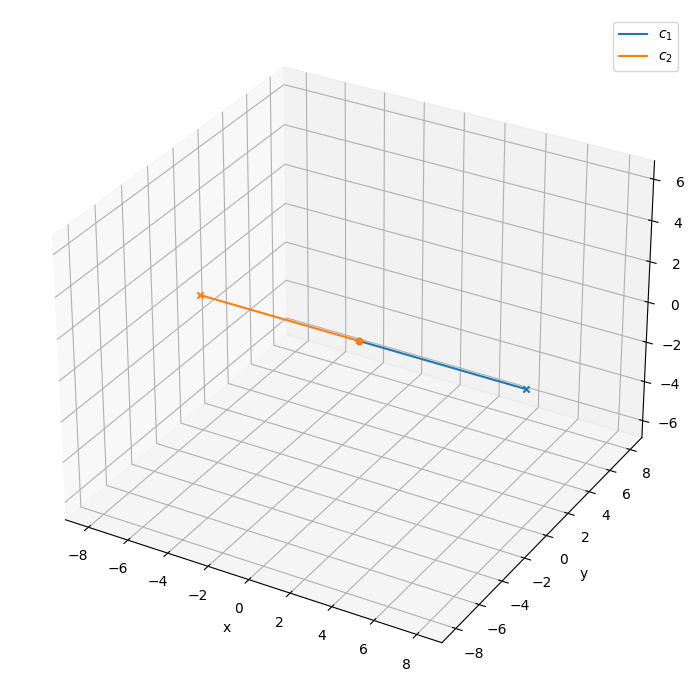

In [15]:
c1_x = hor1.get_ah_property("centroid_x")
c1_y = hor1.get_ah_property("centroid_y")
c1_z = hor1.get_ah_property("centroid_z")

c2_x = hor2.get_ah_property("centroid_x")
c2_y = hor2.get_ah_property("centroid_y")
c2_z = hor2.get_ah_property("centroid_z")

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection='3d')
plt.tight_layout()

ax.plot(c1_x.values, c1_y.values, c1_z.values, color="C0", label='$c_1$')
ax.plot(c2_x.values, c2_y.values, c2_z.values, color="C1", label='$c_2$')

ax.scatter(c1_x.values[0],  c1_y.values[0],  c1_z.values[0],  color="C0", marker="x", s=20, zorder=10)
ax.scatter(c2_x.values[0],  c2_y.values[0],  c2_z.values[0],  color="C1", marker="x", s=20, zorder=10)
ax.scatter(c1_x.values[-1], c1_y.values[-1], c1_z.values[-1], color="C0", marker="o", s=20, zorder=10)
ax.scatter(c2_x.values[-1], c2_y.values[-1], c2_z.values[-1], color="C1", marker="o", s=20, zorder=10)

ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend();

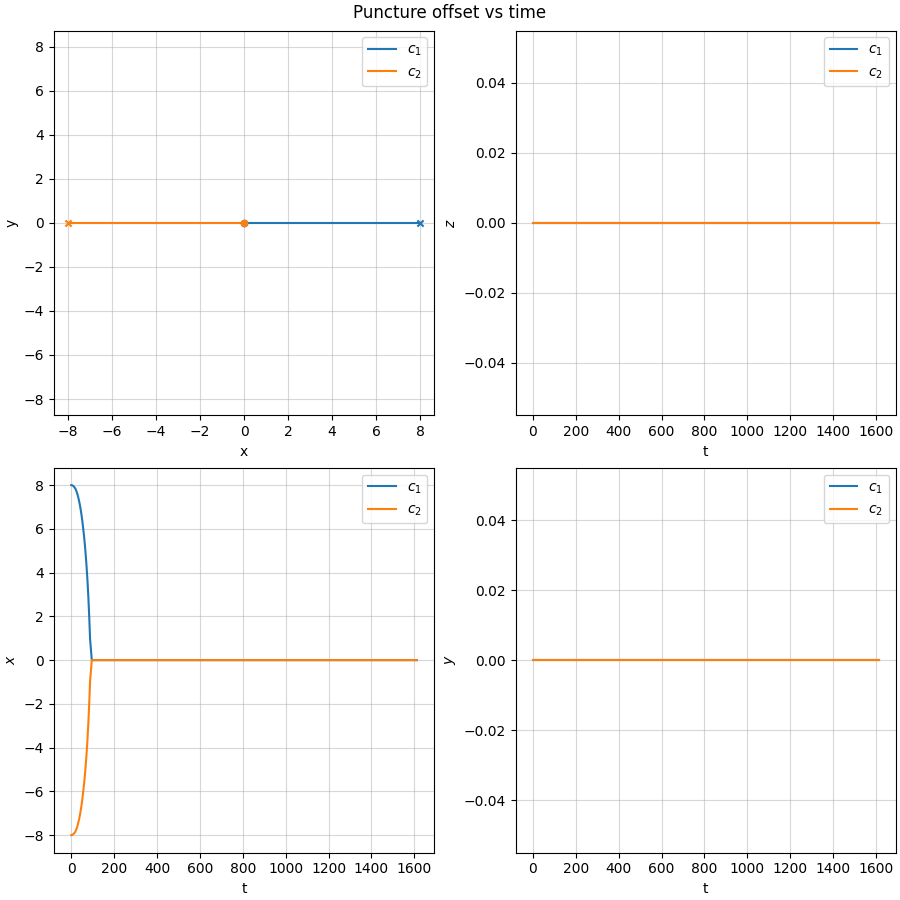

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(9,9), constrained_layout=True)
plt.suptitle("Puncture offset vs time")


ax[0,0].plot(c1_x.values, c1_y.values, color="C0", label=r"$c_1$")
ax[0,0].plot(c2_x.values, c2_y.values, color="C1", label=r"$c_2$")

ax[0,0].scatter([c1_x.values[0]],   [c1_y.values[0]],   color="C0", marker="x", s=20, zorder=10)
ax[0,0].scatter([c2_x.values[0]],   [c2_y.values[0]],   color="C1", marker="x", s=20, zorder=10)
ax[0,0].scatter([c1_x.values[-1]],  [c1_y.values[-1]],  color="C0", marker="o", s=20, zorder=10)
ax[0,0].scatter([c2_x.values[-1]],  [c2_y.values[-1]],  color="C1", marker="o", s=20, zorder=10)

ax[0,0].set_aspect('equal', adjustable='datalim')
ax[0,0].grid(alpha=0.5, zorder=-10)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
ax[0,0].legend()


ax[0,1].plot(c1_z.t, c1_z.values, color="C0", label=r"$c_1$")
ax[0,1].plot(c2_z.t, c2_z.values, color="C1", label=r"$c_2$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_ylabel(r"$z$")
ax[0,1].legend();


ax[1,0].plot(c1_x.t, c1_x.values, color="C0", label=r"$c_1$")
ax[1,0].plot(c2_x.t, c2_x.values, color="C1", label=r"$c_2$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_ylabel(r"$x$")
ax[1,0].legend();


ax[1,1].plot(c1_y.t, c1_y.values, color="C0", label=r"$c_1$")
ax[1,1].plot(c2_y.t, c2_y.values, color="C1", label=r"$c_2$")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel("t")
ax[1,1].set_ylabel(r"$y$")
ax[1,1].legend();

# Global quantities

KeyError: 

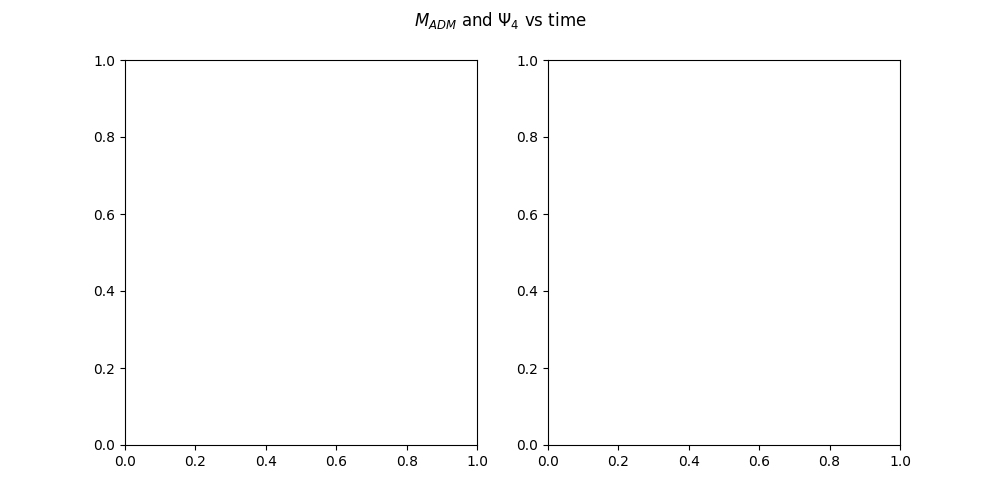

In [17]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))
plt.suptitle(r"$M_{ADM}$ and $\Psi_4$ vs time")

R = 240

M = hor[5,6].adm_energy
psi4_22 = muls["Psi4"][R][(2,2)]

ax1.plot(M.t, M.y, color="C0", label=r"$M_{ADM}$")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.legend()

ax2.plot(psi4_22.t, psi4_22.y.real, color="C1", label=r"$Re \left(\Psi_4^{(22)} \right)$")

ax2.grid(alpha=0.5)
ax2.set_xlabel("t")
ax2.legend();

In [ ]:
# pensar qual dos modos da parte real/imaginário dos Φ1/Φ2 quero dar plot

# E.M. radiation

In [ ]:
# todo: Ex e Ey ao longo de x para um t fixo
# fazer o mesmo para Ey,Ez ao longo de z

# Convergence

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(11.15,14))


ax[0,0].plot(hc_norm.t,      2**4*hc_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{H}_{2}||$")
ax[0,0].plot(hc_norm_res2.t,      hc_norm_res2.y, marker=".", label=r"$             ||\mathcal{H}_{4}||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel("t")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


ax[0,1].plot(Ec_norm.t,      2**4*Ec_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{E}_{2}||$")
ax[0,1].plot(Ec_norm_res2.t,      Ec_norm_res2.y, marker=".", label=r"$             ||\mathcal{E}_{4}||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


ax[1,0].plot(Bc_norm.t,      2**4*Bc_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{B}_{2}||$")
ax[1,0].plot(Bc_norm_res2.t,      Bc_norm_res2.y, marker=".", label=r"$             ||\mathcal{B}_{4}||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic Field")
ax[1,0].legend();


ax[1,1].plot(mcx_norm.t,      2**4*mcx_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{M}_x^{(h=2)}||$")
ax[1,1].plot(mcx_norm_res2.t,      mcx_norm_res2.y, marker=".", label=r"$             ||\mathcal{M}_x^{(h=4)}||$")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel("t")
ax[1,1].set_yscale("log")
ax[1,1].set_title(r"$\mathcal{M}_x$")
ax[1,1].legend();


ax[2,0].plot(mcy_norm.t,      2**4*mcy_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{M}_y^{(h=2)}||$")
ax[2,0].plot(mcy_norm_res2.t,      mcy_norm_res2.y, marker=".", label=r"$             ||\mathcal{M}_y^{(h=4)}||$")

ax[2,0].grid(alpha=0.5)
ax[2,0].set_xlabel("t")
ax[2,0].set_yscale("log")
ax[2,0].set_title(r"$\mathcal{M}_y$")
ax[2,0].legend();


ax[2,1].plot(mcz_norm.t,      2**4*mcz_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{M}_z^{(h=2)}||$")
ax[2,1].plot(mcz_norm_res2.t,      mcz_norm_res2.y, marker=".", label=r"$             ||\mathcal{M}_z^{(h=4)}||$")

ax[2,1].grid(alpha=0.5)
ax[2,1].set_xlabel("t")
ax[2,1].set_yscale("log")
ax[2,1].set_title(r"$\mathcal{M}_z$")
ax[2,1].legend();

# Sketches

In [ ]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection='3d')
plt.tight_layout()

t = np.linspace(0,9)
ax.plot(np.cos(t), np.sin(t), 0.1*t, color="C0", label='$c_1$')
ax.plot(np.sin(t), np.cos(t), 0.1*t, color="C1", label='$c_2$')

ax.scatter(np.cos(0), np.sin(0), 0.1*0, color="C0", marker="x", s=20, zorder=10)
ax.scatter(np.sin(0), np.cos(0), 0.1*0, color="C1", marker="x", s=20, zorder=10)
ax.scatter(np.cos(9), np.sin(9), 0.1*9, color="C0", marker="o", s=20, zorder=10)
ax.scatter(np.sin(9), np.cos(9), 0.1*9, color="C1", marker="o", s=20, zorder=10)

ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend();

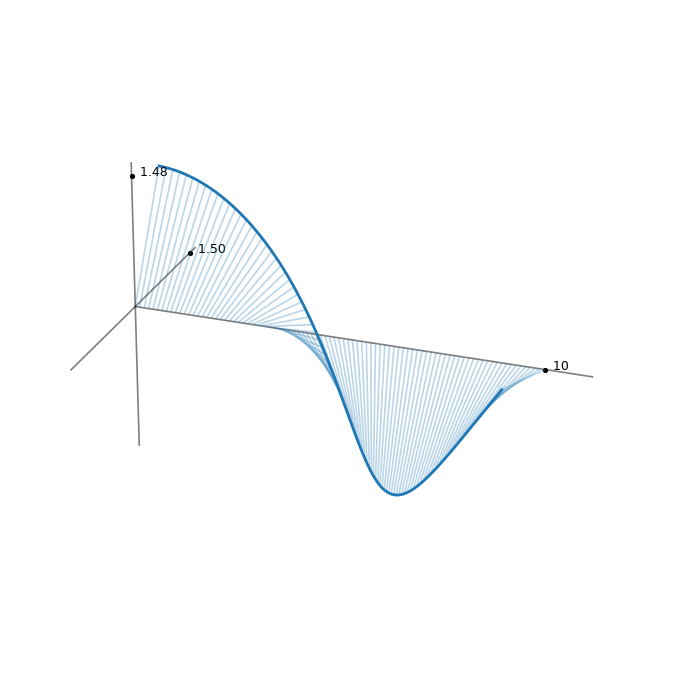

In [17]:
# parameters
N_interp = 300  # Nº of points to plot the interpolated curve (purely aesthetic)
N_teeth  = 90   # Nº of teeth for the comb (independent of the length)
pad = 1.1       # padding (multiplication factor) for maximum/minimum of the reference lines

# mock data
x  = np.linspace(1,10,9)
Vy = 1.5*np.sin(0.5*x)
Vz = 1.5*np.cos(0.5*x)

# create the plot
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# plot the reference lines
Vy_max = max(abs(Vy.min()), abs(Vy.max()))
Vz_max = max(abs(Vz.min()), abs(Vz.max()))

x_lo, x_hi = x.min(), pad * x.max()
y_lo, y_hi = -pad * Vy_max, pad * Vy_max
z_lo, z_hi = -pad * Vz_max, pad * Vz_max

ax.plot([x_lo,x_hi], [0,0],       [0,0],       color='black', linewidth=1.2, alpha=0.5)
ax.plot([x_lo,x_lo], [y_lo,y_hi], [0,0],       color='black', linewidth=1.2, alpha=0.5)
ax.plot([x_lo,x_lo], [0, 0],      [z_lo,z_hi], color='black', linewidth=1.2, alpha=0.5)

# plot interpolated curve (x, Vy(x), Vz(x))
Vy_of_x = CubicSpline(x, Vy)
Vz_of_x = CubicSpline(x, Vz)

x_fine = np.linspace(x.min(), x.max(), N_interp)
Vy_fine = Vy_of_x(x_fine)
Vz_fine = Vz_of_x(x_fine)

ax.plot(x_fine, Vy_fine, Vz_fine, color="C0", linewidth=2)

# plot the comb lines
x_teeth = np.linspace(x.min(), x.max(), N_teeth)
Vy_teeth = Vy_of_x(x_teeth)
Vz_teeth = Vz_of_x(x_teeth)

origins = np.column_stack([x_teeth, np.zeros(N_teeth), np.zeros(N_teeth)])
teeth_offsets = np.column_stack([np.zeros(N_teeth), Vy_teeth, Vz_teeth])

ax.quiver(
    origins[:, 0], origins[:, 1], origins[:, 2],
    teeth_offsets[:, 0], teeth_offsets[:, 1], teeth_offsets[:, 2],
    color="C0", alpha=0.3, linewidth=1.2, arrow_length_ratio=0.0
)

# mark the maximum of x, Vy and Vz on their reference lines
ax.scatter([x.min()], [Vy_max], [0],      color='black', marker=".", s=30, zorder=5)
ax.scatter([x.min()], [0],      [Vz_max], color='black', marker=".", s=30, zorder=5)
ax.scatter([x.max()], [0],      [0],      color='black', marker=".", s=30, zorder=5)

ax.text(x.min(), Vy_max, 0,      f'  {Vy_max:.2f}',   color='black', fontsize=9)
ax.text(x.min(), 0,      Vz_max, f'  {Vz_max:.2f}',   color='black', fontsize=9)
ax.text(x.max(), 0,      0,      f'  {int(x.max())}', color='black', fontsize=9)

# axis limits and aspect ratio
# y and z have the same scale, the scale for the x-axis is arbitrary
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_zlim(z_lo, z_hi)

ax.set_box_aspect([5, y_hi-y_lo, z_hi-z_lo])

plt.tight_layout()

# hide all background graphics
ax.set_axis_off();

# defualt viewing angle
ax.view_init(elev=25, azim=-70);